<a href="https://colab.research.google.com/github/hector1994/session_4_sprint7_95_1/blob/main/%F0%9F%8C%AA%EF%B8%8FTT_DA_107_SPRINT_4_SQL_FUNNEL_ANALYSIS%F0%9F%93%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# __📊SQL WORK ENVIROMENT. E-COMMERCE FUNNEL DATA ANALYSIS 🛍️🧑‍💻__
---


## 🚨 __¿Cómo usar este archivo?__ 🤷🏻‍♂️

<p align="justify">
El presente archivo se constituye como una herramienta generadora de ambiente para el desarrollo de código SQL en Google Colab. Sus objetivo son: </p>

* <p align="justify"> Permitir al estudiante acceder a una base de datos que cuenta con más de 2,000,000 de registros asociados a variables típicas encontradas en el análisis de un e-commerce (retail):. </p>

* <p align="justify"> Generar un ambiente del trabajo donde los estudiantes puedan escribir, depurar y generar código SQL para realizar cosultas sobre la base de datos generada. </p>

* <p align="justify"> Aprender a usar SQL como herramienta de comunicación de insights y como pueden utilizarse para responder la pregunta de negocio o hipótesis que sea de interés para los stakeholders.
</p>

* <p align="justify">  Generar instancias que impliquen el manejo simultaneo de múltiples tablas en una base de datos.
</p>

<p align="justify">
El contexto viene dado por una 👉<b><a href="https://github.com/hector1994/e_commerce_funnel_data_generator/blob/master/customer_journey_data_generator.ipynb">generación de data de eventos  de e-commerce</a></b> 👈, que tiene por finalidad generar una instancia que permite al estudiante comprender la relación entre tablas, generación de consultas SQL de distinta complejidad, uso de CTE, filtros, sumarios, subconsultas, entro otros conceptos.

Adicionalmente, se entenderá el concepto de análisis de funnel, el cual es un concepto bastante común en el ámbito del comercio digital y como acceder a este tipo de insights se constituyen como una gran herramienta para la administración general de un negocio de comercio virtual.
</p>

---

##🖊️📖✏️📚 __INSTRUCCIONES DE USO__ 📋

 <p align="justify">

* __STEP 1️⃣:__ <p align="justify">  El chunk de código que viene a continuación tiene <b>dos funciones principales:</b>
</p>

<p align="justify">

**(1) Conectar** nuestro entorno con las bases de datos generadas para nuestro propósito de aprendizaje.
</p>

<p align="justify">

**(2) Generar un entorno de programación en SQL** idéntico a los motores frecuentemente usados en la industrial.
</p>

<p align="justify">
<b>Si es de su interés</b>, puedes hacer click en el botón ✨<b><font color="green">Mostrar código</font></b>✨, para poder ver con todo detalle el proceso mencionado en (1) y (2). Si no es así, simplemente omita esta opción. Sea cual sea el caso, <b><font color="red">debe dar click en el botón de run</font> </b> para poder generar la base de datos y activar el ambiente.
</p>

<p align = "justify">
Listo! La base de datos ha sido generada y ya podemos ver las tablas disponibles (rutas). También el ambiente para poder generar SQL-queries ha sido activado.
</p>

* __STEP 2️⃣:__ <p align="justify">

 Listo! Luego del paso anterior, ya puedes comenzar a generar consultas en este Google Colab y consultar la base de datos que ha sido generada (usando sus rutas). Para eso, simplemente debemos crear un nuevo chunck de código y escribir la <b><font color="cian">palabra mágica:</font></b> <b><font color="blue">%%sql</font></b>✨ en nuestro chunck de código y listo ✅, en ese chunck puedes ejecutar código SQL como lo harías en cualquier plataforma 🛢️.
</p>


In [ ]:
#@title 🛢️📊 __STEP 1:__ Conectémonos a nuestra base de datos y activemos nuestro ambiente 🚀 { display-mode: "form" }
import pandas as pd
import sqlite3
import time
from   tqdm.notebook import tqdm
from   IPython.core.magic import register_cell_magic
from   IPython.display import display, HTML, clear_output
pd.set_option('display.max_columns', None)  # Elimina el límite de columnas
pd.set_option('display.expand_frame_repr', False) # Evita que la tabla se "rompa" en varias líneas

# 1. Configuración de enlaces (URL LFS Directa)
datasets = {
    'ecommerce_events': "https://media.githubusercontent.com/media/hector1994/e_commerce_funnel_data_generator/refs/heads/master/data_clase_sql_final_mejorado.csv"
}

# 2. Conexión a la base de datos en memoria
# Aumentamos el timeout para procesar el gran volumen de datos
connector = sqlite3.connect(':memory:', check_same_thread=False)

# 3. Proceso de carga con Barra de Progreso
print("⬇️🗂️ Descargando y sincronizando Dataset Masivo (2.1M registros).....🔄⚙️")
summary_data = []

for name, url in tqdm(datasets.items(), desc="Cargando Tablas"):
    # Descarga de datos
    df = pd.read_csv(url)

    # --- CAMBIO IMPORTANTE: DEFINICIÓN DE FECHAS ---
    # Convertimos la columna de timestamp a formato datetime real
    if 'event_timestamp' in df.columns:
        df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

    # Conversión a SQL (con chunksize para optimizar memoria)
    df.to_sql(name, connector, index=False, if_exists='replace', chunksize=10000)

    # Guardar info para el resumen
    summary_data.append({
        "Table Name": f"{name}",
        "Rows": f"{len(df):,}",
        "Columns": len(df.columns)
    })

# 4. Definición de la "Palabra mágica" %%sql
@register_cell_magic
def sql(line, cell):
    try:
        # Ejecución de la consulta
        resultado = pd.read_sql(cell, connector)
        clear_output(wait=True)
        display(HTML("<b style='color: #4CAF50;'>✅ Query completed successfully:</b>"))
        return display(resultado)
    except Exception as e:
        clear_output(wait=True)
        display(HTML(f"<b style='color: #F44336;'>❌ Query execution failed:</b><br><code style='color: grey;'>{str(e)}</code>"))

# 5. Interfaz final para el alumno
clear_output()
display(HTML("<h2 style='color: #8e62f3'>✨ Database initialized. E-commerce Funnel Data ✨</h2>"))
display(HTML("<p>The 2.1M rows dataset has been loaded. You can now use <b>ecommerce_events</b> in your queries:</p>"))

# Mostramos el resumen
display(pd.DataFrame(summary_data))
print("\n ✨🚀 SYSTEM READY! START ANALYZING THE FUNNEL! 🚀✨")

,Table Name,Rows,Columns
0,ecommerce_events,"2,100,000",12



 ✨🚀 SYSTEM READY! START ANALYZING THE FUNNEL! 🚀✨


#### 📶 __Análisis de Funnels y Micro-Momentos: Desvelando la Fuga de Conversión__💎

<p align = 'justify'>
El análisis de funnel o embudo de conversión es una de las piedras angulares en el trabajo de un Data Analyst, especialmente en entornos de e-commerce y productos digitales. Este proceso se basa en el seguimiento de una serie de eventos específicos, que son acciones discretas realizadas por el usuario, como <code>page_view </code>, <code>add_to_cart</code> y finalmente <code>purchase</code>. El concepto de efecto funnel describe cómo el volumen de usuarios disminuye inevitablemente a medida que avanzan en el flujo; por ejemplo, miles de personas pueden ver un producto, pero solo una fracción lo añade al carrito y un grupo aún menor completa el pago. La diferencia entre los usuarios que inician un paso y los que completan el siguiente se conoce como fuga o churn del funnel. Identificar dónde es más pronunciada esta fuga permite al analista señalar cuellos de botella críticos, donde pequeños ajustes en la interfaz o en la estrategia de marketing podrían recuperar ingresos significativos.
 </p>

 <p align = 'justify'>
 En la práctica técnica, el uso de SQL es la herramienta estándar y más potente para construir estos modelos de análisis. Un Data Analyst utiliza SQL para segmentar estos embudos por dimensiones como el país, el tipo de dispositivo o el nivel de membresía (Bronze, Silver, Gold), lo que permite descubrir si la fuga es un problema técnico de una plataforma específica o una falta de interés de un segmento de clientes particular. La capacidad de transformar millones de registros crudos en una tabla limpia de porcentajes de conversión es lo que separa un reporte descriptivo de uno verdaderamente accionable.
 </p>

 <p align = 'justify'>
 La frecuencia con la que se requiere este análisis en la industria es altísima, siendo prácticamente una tarea diaria en equipos de Producto y Crecimiento (Growth). En un mercado competitivo, las empresas no pueden permitirse ignorar por qué están perdiendo clientes en medio de un proceso de compra. Los beneficios de dominar esta técnica son directos: permite la optimización de la tasa de conversión (CRO), justifica inversiones en rediseño de UX basadas en datos duros y mejora el retorno de inversión publicitaria (ROAS). Al final del día, el análisis de funnel no solo reporta qué sucedió, sino que proporciona el mapa necesario para que el negocio sepa exactamente dónde intervenir para maximizar la retención y el valor de vida del cliente (LTV).</p>

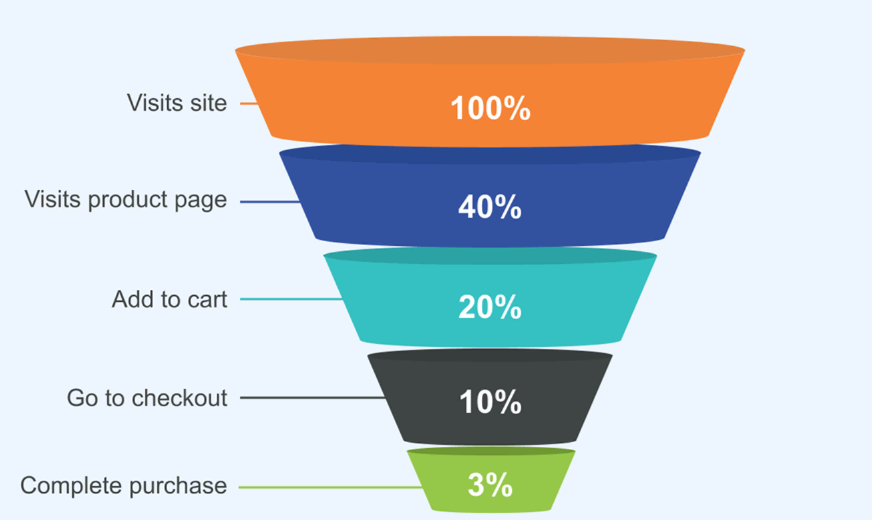


#### 🗺️ __Customer Journey: Definición de Eventos del Embudo__ 🔍
#### 🛠️ Diccionario del Flujo de Usuario

| ID | Evento | Descripción Técnica | Clasificación |
| :--- | :--- | :--- | :--- |
| **0** | <font color="#7abaff">`home_page`</font> | Carga inicial del sitio. Punto de partida de la sesión. | <font color="#7abaff">Navegación</font> |
| **1** | <font color="#7abaff">`log_in`</font> | El usuario se identifica. Permite rastrear su historial. | <font color="#7abaff">Identificación</font> |
| **2** | <font color="#7abaff">`page_view`</font> | Visualización de subpáginas o contenido informativo. | <font color="#7abaff">Navegación</font> |
| **3** | <font color="#ffd43b">`click_product`</font> | Interés específico en un ítem del catálogo. | <font color="#ffd43b">Interacción</font> |
| **4** | <font color="#ffd43b">`add_to_cart`</font> | Intención de compra. El producto entra en la cesta. | <font color="#ffd43b">Interés Alto</font> |
| **5** | <font color="#ff6b6b">`begin_checkout`</font> | Inicio del proceso de pago y logística de envío. | <font color="#ff6b6b">Checkout</font> |
| **6** | <font color="#ff6b6b">`end_checkout`</font> | Revisión final. Último paso antes de procesar el pago. | <font color="#ff6b6b">Checkout</font> |
| **7** | <font color="#8ce99a">`purchase`</font> | **Conversión final.** Se registra el `payment_method` e ingreso. | <font color="#8ce99a">Conversión</font> |

---

###  👩🏻‍💻🕵🏻‍♂️ __STEP 2: Comencemos a hacer consultas!__ 🗂️📡👩🏻‍💻

In [ ]:
%%sql
SELECT * FROM ecommerce_events LIMIT 2


,event_timestamp,user_id,session_id,event_name,country,traffic_source,device,sku,cart_id,payment_method,units,amount
0,2026-01-11 05:48:18,17176,6567177D-1AB5-41C0,home_page,Chile,Google Search,Desktop,None,None,None,0,0.0
1,2026-01-11 05:48:38,17176,6567177D-1AB5-41C0,login,Chile,Google Search,Desktop,None,None,None,0,0.0


In [ ]:
%%sql
--CANTIDAD DE EVENTOS REGISTRADOS POR EL MARKETPLACE
SELECT
COUNT(*) AS conteo_total_eventos
FROM ecommerce_events


,conteo_total_eventos
0,2100000


In [ ]:
%%sql
--EN QUE INTERVALO DE TIEMPO SE DIERON ESO EVENTOS?
SELECT
MIN(event_timestamp) AS fecha_incio,
MAX(event_timestamp) AS fecha_final
FROM ecommerce_events

,fecha_incio,fecha_final
0,2026-01-01 00:00:01,2026-02-01 00:07:16


In [ ]:
%%sql
--CUANTOS USUARIOS HAY EN LA BASE DE DATOS?
SELECT
COUNT(DISTINCT user_id) AS total_usuarios
FROM ecommerce_events

,total_usuarios
0,89735


In [ ]:
%%sql
--CUANTAS SESIONES?
SELECT
COUNT(DISTINCT session_id) AS total_sesiones
FROM ecommerce_events


,total_sesiones
0,519787


In [ ]:
%%sql
--CUANTOS EVENTOS HAY REGISTRADOS? Y CUANTOS HAY POR EVENTO?
SELECT
event_name,
COUNT(*) AS conteo_eventos,
COUNT(DISTINCT user_id) as users_count

FROM ecommerce_events
GROUP BY 1
ORDER BY 3 DESC

,event_name,conteo_eventos,users_count
0,home_page,519787,89735
1,login,390101,88848
2,product_view,623316,87184
3,add_to_cart,169535,64474
4,begin_checkout,144197,61550
5,end_checkout,129890,59382
6,purchase,123174,58163


In [ ]:
%%sql

In [ ]:
%%sql
--GENERAR UNA CONSULTA SQL QUE ME DIGA DE QUE traffic_source VIENEN LOS USUARIOS
SELECT
traffic_source AS origen,
COUNT(DISTINCT user_id) AS total_usuarios

FROM ecommerce_events
GROUP BY 1
ORDER BY 2 DESC


,origen,total_usuarios
0,Social Media,85095
1,Google Search,68568
2,Direct,61584
3,Email Campaign,22561


In [ ]:
%%sql
--CUANTOS USUARIOS HAN AGREGADO AL CARRITO? (add_to_cart)

SELECT
*
FROM ecommerce_events  WHERE event_name = "add_to_cart"

,event_timestamp,user_id,session_id,event_name,country,traffic_source,device,sku,cart_id,payment_method,units,amount
0,2026-01-20 04:15:08,66728,6C0C0512-A867-40BB,add_to_cart,Colombia,Direct,Mobile,SKU-897,CART-71439,None,0,0.0
1,2026-01-20 04:15:08,66728,6C0C0512-A867-40BB,add_to_cart,Colombia,Direct,Mobile,SKU-187,CART-71439,None,0,0.0
2,2026-01-23 14:39:22,24840,E170249A-8190-4CDD,add_to_cart,México,Social Media,Mobile,SKU-881,CART-64624,None,0,0.0
3,2026-01-19 03:25:07,59137,C815C184-8C83-45CC,add_to_cart,Argentina,Social Media,Desktop,SKU-932,CART-40090,None,0,0.0
4,2026-01-12 03:17:33,57051,FD3CF9A7-E898-44A6,add_to_cart,Colombia,Email Campaign,Mobile,SKU-932,CART-63546,None,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
169530,2026-01-21 13:13:50,56319,6F28807E-99D8-4D73,add_to_cart,España,Direct,Mobile,SKU-999,CART-17015,None,0,0.0
169531,2026-01-21 13:13:50,56319,6F28807E-99D8-4D73,add_to_cart,España,Direct,Mobile,SKU-184,CART-17015,None,0,0.0
169532,2026-01-01 07:39:32,81460,F32D3640-F2E5-4723,add_to_cart,México,Direct,Tablet,SKU-253,CART-94378,None,0,0.0
169533,2026-01-27 13:13:47,73565,0F9C1EBA-5A41-4572,add_to_cart,Chile,Social Media,Mobile,SKU-921,CART-99757,None,0,0.0


In [ ]:
%%sql

WITH

purchase_cte AS
(
  SELECT
  *
  FROM ecommerce_events
  WHERE event_name = 'purchase'
),

homepage_cte AS (
  SELECT
  *
  FROM ecommerce_events
  WHERE event_name = 'home_page'
),

add_to_cart_co_cte AS (
  SELECT
  *
  FROM ecommerce_events
  WHERE event_name = 'add_to_cart'        AND
        country    =   "Colombia"              AND
        traffic_source = 'Email Campaign' AND
        device = 'Mobile'
        )

SELECT count(distinct user_id) FROM add_to_cart_co_cte --TABLA DE PERSONAS QUE AGREGAN AL CARRITO DE COLOMBIA POR SU CELULAR DESDE EMAIL CAMPAIGN

,count(distinct user_id)
0,1318


In [ ]:
%%sql

SELECT
  *
  FROM ecommerce_events
  WHERE event_name = 'purchase'

,event_timestamp,user_id,session_id,event_name,country,traffic_source,device,sku,cart_id,payment_method,units,amount
0,2026-01-20 04:15:38,66728,6C0C0512-A867-40BB,purchase,Colombia,Direct,Mobile,SKU-187,CART-71439,Debit Card,1,123.42
1,2026-01-23 14:39:52,24840,E170249A-8190-4CDD,purchase,México,Social Media,Mobile,SKU-881,CART-64624,Crypto,2,107.77
2,2026-01-19 03:25:37,59137,C815C184-8C83-45CC,purchase,Argentina,Social Media,Desktop,SKU-932,CART-40090,PayPal,2,109.68
3,2026-01-16 19:52:41,82720,DE2439F2-024A-489D,purchase,México,Google Search,Tablet,SKU-366,CART-26211,Debit Card,1,100.55
4,2026-01-16 19:52:41,82720,DE2439F2-024A-489D,purchase,México,Google Search,Tablet,SKU-904,CART-26211,Debit Card,2,43.44
5,2026-01-20 00:37:42,84936,D1857ECB-D75F-41FE,purchase,Colombia,Direct,Mobile,SKU-135,CART-41753,Credit Card,1,42.48
6,2026-01-03 14:01:36,47196,9D89795E-0461-4260,purchase,México,Social Media,Desktop,SKU-874,CART-46230,Credit Card,2,118.66
7,2026-01-28 01:34:27,33245,40565101-4F23-4A2F,purchase,Argentina,Google Search,Desktop,SKU-550,CART-13394,Credit Card,1,57.99
8,2026-01-23 00:16:53,98951,DCAD62B6-0146-4231,purchase,México,Google Search,Mobile,SKU-921,CART-60107,Debit Card,2,79.73
9,2026-01-23 12:18:05,98534,EB6F1038-49F9-49B6,purchase,Argentina,Google Search,Mobile,SKU-111,CART-22421,Crypto,2,109.83


## __Common Table Expressions (CTE's)__
---

In [ ]:
%%sql
SELECT * FROM ecommerce_events LIMIT 3

,event_timestamp,user_id,session_id,event_name,country,traffic_source,device,sku,cart_id,payment_method,units,amount
0,2026-01-11 05:48:18,17176,6567177D-1AB5-41C0,home_page,Chile,Google Search,Desktop,None,None,None,0,0.0
1,2026-01-11 05:48:38,17176,6567177D-1AB5-41C0,login,Chile,Google Search,Desktop,None,None,None,0,0.0
2,2026-01-11 05:50:38,17176,6567177D-1AB5-41C0,product_view,Chile,Google Search,Desktop,SKU-758,None,None,0,0.0


In [ ]:
%%sql
--EXTRACCIÓN DE CADA EVENTO DESDE NUESTRA TABLA PRINCIPAL (TABLA DE HECHOS) UTILIZANDO CTE's
SELECT  DISTINCT event_name FROM ecommerce_events

,event_name
0,home_page
1,login
2,product_view
3,add_to_cart
4,begin_checkout
5,end_checkout
6,purchase


In [ ]:
%%sql
--PARTE 1: SEPARAR LOS EVENTOS/PASOS/ETAPAS/ESTADOS DEL USUARIO DENTRO DE SU JOURNEY.
WITH
--1
homepage_cte AS (
SELECT *
FROM ecommerce_events
WHERE event_name = "home_page"
),
--2
login_cte AS (
SELECT *
FROM ecommerce_events
WHERE event_name = "login"
),
--3
product_view_cte AS (
SELECT *
FROM ecommerce_events
WHERE event_name = "product_view"
),
--4
add_to_cart_cte AS (
SELECT *
FROM ecommerce_events
WHERE event_name = "add_to_cart"
),
--5
begin_checkout_cte AS (
SELECT *
FROM ecommerce_events
WHERE event_name = "begin_checkout"
),
--6
end_checkout_cte AS (
SELECT *
FROM ecommerce_events
WHERE event_name = "end_checkout"
),
--7
purchase_cte AS (
SELECT *
FROM ecommerce_events
WHERE event_name = "purchase"
)

--PARTE 2: GENEREMOS REPORTE DE KPIS ABSOLUTOS DE RETENCIÓN PARA NUESTRO E-COMMERCE

SELECT --GRAN SELECT

--KPIS ABSOLUTOS DE RETENCIÓN
(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)       AS home_page,     --1
(SELECT COUNT(DISTINCT user_id) FROM login_cte)          AS login,         --2
(SELECT COUNT(DISTINCT user_id) FROM product_view_cte)   AS product_view,  --3
(SELECT COUNT(DISTINCT user_id) FROM add_to_cart_cte)    AS add_to_cart,    --4
(SELECT COUNT(DISTINCT user_id) FROM begin_checkout_cte) AS begin_checkout, --5
(SELECT COUNT(DISTINCT user_id) FROM end_checkout_cte)   AS end_checkout,   --6
(SELECT COUNT(DISTINCT user_id) FROM purchase_cte)       AS purchase,       --7



--KPIS RELATIVOS DE RETENCIÓN
100.00*(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)/(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)        AS tc_homepage,

100.00*(SELECT COUNT(DISTINCT user_id) FROM login_cte)/(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)           AS tc_login,

100.00*(SELECT COUNT(DISTINCT user_id) FROM product_view_cte)/(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)    AS tc_product_view,

100.00*(SELECT COUNT(DISTINCT user_id) FROM add_to_cart_cte)/(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)     AS tc_add_to_cart,

100.00*(SELECT COUNT(DISTINCT user_id) FROM begin_checkout_cte)/(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)  AS tc_begin_checkout,

100.00*(SELECT COUNT(DISTINCT user_id) FROM end_checkout_cte)/(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)    AS tc_end_checkout,

100.00*(SELECT COUNT(DISTINCT user_id) FROM purchase_cte)/(SELECT COUNT(DISTINCT user_id) FROM homepage_cte)        AS tc_purchase







,home_page,login,product_view,add_to_cart,begin_checkout,end_checkout,purchase,tc_homepage,tc_login,tc_product_view,tc_add_to_cart,tc_begin_checkout,tc_end_checkout,tc_purchase
0,89735,88848,87184,64474,61550,59382,58163,100.0,99.011534,97.157185,71.849334,68.590851,66.174848,64.816404


###📚 __Query 1:__ Identificación de "Super-Compradores" por país.

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ Utilizaremos un CTE para agrupar primero el gasto total por cada usuario. Luego, en la consulta principal, filtraremos aquellos usuarios cuyo gasto sea superior a los 500 USD, ordenándolos de mayor a menor.

In [ ]:
%%sql

###📚 __Query 2:__ KPI de conversión global en cada registro (Uso de Escalares)

__Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

Descripción: Utilizaremos subconsultas escalares en el <code>SELECT</code> para calcular el total de vistas y el total de compras de toda la tabla de forma independiente.

In [ ]:
%%sql


###📚 __Query 3:__ Clasificación de sesiones según volumen de artículos (Categorización lógica)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ Crearemos una columna calculada llamada tipo_carrito utilizando CASE WHEN. Si en una sesión se compraron más de 5 unidades será 'Compra Mayorista', entre 2 y 5 'Compra Familiar', y solo 1 será 'Compra Individual'.

In [ ]:
%%sql


###📚 __Query 4:__ Análisis de representatividad de ingresos (Uso de Escalares)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).
* __Descripción:__ Usaremos una subconsulta escalar para obtener el ingreso total histórico de la empresa y compararlo con el ingreso de cada país para calcular qué porcentaje del dinero total aporta cada nación.

In [ ]:
%%sql

###📚 __Query 5:__ Desempeño de dispositivos vs. Promedio Global (Uso de Escalares)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ Compararemos el Ticket Promedio (AOV) de cada tipo de dispositivo contra el promedio de venta de toda la plataforma utilizando una subconsulta escalar en el SELECT.

In [ ]:
%%sql



###📚 __Query 6:__ Ranking de fuentes de tráfico por volumen de usuarios (Uso de CTE)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ En marketing es vital saber qué canal trae más personas, no solo cuántos clics hay. Utilizaremos un CTE para pre-calcular la cantidad de usuarios únicos (user_id) que atrajo cada fuente de tráfico (traffic_source). Luego, en la consulta principal, mostraremos el ranking de las fuentes más efectivas.

In [ ]:
%%sql

###📚 __Query 7:__ Detección de SKUs de alta rotación (Uso de HAVING)

__Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

__Descripción:__ Necesitamos identificar qué productos específicos son "Best Sellers". Para ello, sumaremos todas las unidades vendidas por cada SKU. Sin embargo, solo nos interesan aquellos productos que hayan superado las 100 unidades vendidas en total.

In [ ]:
%%sql

###📚 __Query 8:__ Segmentación de Clientes por Nivel de Gasto (Loyalty)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ El objetivo es etiquetar a cada cliente según su valor para la empresa. Primero, usaremos un CTE para calcular cuánto ha gastado cada usuario en total. Luego, aplicaremos una lógica de tres niveles: si gastó más de 1,000 USD es 'Diamond', entre 500 y 1,000 es 'Gold', y si es menos de 500 es 'Silver'.

In [ ]:
%%sql

###📚 __Query 9:__ Peso de Métodos de Pago vs. Volumen Total (Uso de Escalares)

* __Tablas involucradas:__ Ecommerce Events - (ecommerce_events).

* __Descripción:__ Queremos saber qué porcentaje de las compras se realizan con cada método (Tarjeta de Crédito, PayPal, etc.). Para esto, contaremos cuántas veces se usó cada método y lo compararemos contra el total de compras de la tabla mediante una subconsulta escalar.

In [ ]:
%%sql